In [1]:
# vamos a examinar como cambia la distribucion de los pesos durante el entrenamiento

Vamos a entrenar este modelo con la tecnica de pesos inicializados. Ahora bien, los resultados si son interesantes, pero no extremadamente perspicaces porque estamos haciendo muy poco entranamiento en el modelo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F

# Gráficos vectoriales
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [3]:
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
# Hiperparámetros para GPT2-124M
n_vocab    = 50257     # Tamaño del vocabulario de GPT-2
embed_dim  =   768     # Dimensión del embedding
seq_len    =   256     # Longitud máxima de secuencia
n_heads    =    12     # Cabezales de atención
n_blocks   =    12     # Bloques de transformer
batch_size =    16

# Usar GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [5]:
# Tokenizar el texto
# Los viajes de Gulliver :)
text = requests.get('https://www.gutenberg.org/cache/epub/829/pg829.txt').text
gtTokens = tokenizer.encode(text)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (158340 > 1024). Running this sequence through the model will result in indexing errors


In [6]:
# División en entrenamiento y prueba (train/test split)
train_ratio = 0.9

# Índice para dividir los datos
test_split_point = int(train_ratio * len(gtTokens))

# Aseguramos que los tokens sean un tensor de PyTorch para soportar indexación avanzada
if not isinstance(gtTokens, torch.Tensor):
  gtTokens = torch.tensor(gtTokens)

train_data = gtTokens[:test_split_point]
test_data = gtTokens[test_split_point:]


# Una función que devuelve un lote de muestras de datos
def get_data_batch(training=True):

  # Elegir el conjunto de datos a usar
  if training:
    data = train_data
  else:
    data = test_data

  # Elegir índices aleatorios de inicio
  ix = torch.randint(len(data) - seq_len, size=(batch_size,))

  # Obtener las entradas y objetivos (mediante broadcasting de producto externo)
  X = data[ix[:, None] + torch.arange(seq_len)]
  y = data[ix[:, None] + torch.arange(1, seq_len + 1)]
  return X, y


# Ejemplo
X, y = get_data_batch()
print(f'Datos de entrada (tamaño {X.shape}):\n', X)
print(f'\n\nObjetivos (tamaño {y.shape}):\n', y)

Datos de entrada (tamaño torch.Size([16, 256])):
 tensor([[  287,  3594,    11,  ...,   976,   640,  2921],
        [  198,  1929,  4316,  ...,  1499,    11,   290],
        [  257,  5448,  2988,  ...,   201,   198,   201],
        ...,
        [ 2494,   543,   314,  ...,  3704,   286, 36076],
        [ 6590,   326,   484,  ...,   201,   198,    79],
        [ 2502,   616,  8242,  ...,  6982,   286, 25411]])


Objetivos (tamaño torch.Size([16, 256])):
 tensor([[ 3594,    11,   543,  ...,   640,  2921,   683],
        [ 1929,  4316,   462,  ...,    11,   290,  1871],
        [ 5448,  2988,    11,  ...,   198,   201,   198],
        ...,
        [  543,   314,   561,  ...,   286, 36076,    12],
        [  326,   484,   750,  ...,   198,    79,   576],
        [  616,  8242,    26,  ...,   286, 25411,    11]])


In [7]:
class MultiHeadAttention(nn.Module):

  def __init__(self):
    super().__init__()

    # Número de cabezales de atención
    self.num_heads = n_heads
    self.head_dim = embed_dim // n_heads

    # Las tres matrices de pesos Q, K, V se inicializan como una sola y se dividen en forward()
    self.QKV = nn.Linear(embed_dim, 3 * embed_dim, bias=True)

    # Mezcla lineal tras la atención
    self.W0 = nn.Linear(embed_dim, embed_dim, bias=True)

  def forward(self, x):

    # Dimensiones para uso posterior
    B, T, E = x.shape  # [lote, seq_len, embed_dim]

    # Pasar los datos a través de Q, K y V en una sola matriz concatenada
    qkv = self.QKV(x)  # [lote, secuencia, 3*embed]
    q, k, v = torch.split(qkv, E, dim=2)  # Cada matriz es [B, T, E]

    # Redimensionar a [B, T, n_cabezales, dim_cabezal]
    # y luego transponer a [B, n_cabezales, T, dim_cabezal]
    q = q.view(B, T, self.num_heads, self.head_dim).transpose(
        1, 2
    )  # [B, n_cabezales, T, dim_cabezal]
    k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    # La función de atención producto punto escalada de PyTorch gestiona dimensiones multi-cabezal
    out = F.scaled_dot_product_attention(
        q, k, v, is_causal=True
    )  # [B, n_cabezales, T, dim_cabezal]

    # Recombinar cabezales: (B, n_cabezales, T, dim_cabezal) -> [B, T, E]
    out = out.transpose(1, 2).contiguous().view(B, T, E)

    # Finalmente, mezclar linealmente los cabezales de atención
    out = self.W0(out)

    return out


class TransformerBlock(nn.Module):

  def __init__(self):
    super().__init__()

    ### Sub-bloque de atención
    self.layernorm_1 = nn.LayerNorm(embed_dim, eps=1e-5)
    self.attn = MultiHeadAttention()

    ### Sub-bloque lineal feedforward (MLP)
    self.layernorm_2 = nn.LayerNorm(embed_dim, eps=1e-5)
    # Expansión 4x y posterior reducción a la dimensión del embedding
    self.mlp_1 = nn.Linear(embed_dim, 4 * embed_dim, bias=True)
    self.gelu = nn.GELU()
    self.mlp_2 = nn.Linear(4 * embed_dim, embed_dim, bias=True)

  def forward(self, x):

    # Atención
    x_att = self.layernorm_1(x)  # Normalización previa a la atención (Pre-LN)
    x_att = x + self.attn(
        x_att
    )  # Pasar por la atención y sumar la activación previa ("residual")

    # MLP
    x_ff = self.layernorm_2(x_att)  # Normalización previa al MLP (Pre-LN)
    x_ff = x_att + self.mlp_2(
        self.gelu(self.mlp_1(x_ff))
    )  # Ajuste tras el paso de expansión y contracción

    return x_ff

## Con pesos Inicializados

In [8]:
class LanguageModel(nn.Module):

  def __init__(self):
    super().__init__()

    # Embeddings de tokens y de posición
    self.wte = nn.Embedding(
        n_vocab, embed_dim
    )  # Embedding de tokens (token embedding)
    self.wpe = nn.Embedding(
        seq_len, embed_dim
    )  # Embedding posicional (position embedding)

    # Bloques de transformer
    self.transformerBlocks = nn.Sequential(
        *[TransformerBlock() for _ in range(n_blocks)]
    )

    # LayerNorm final
    self.layernorm_final = nn.LayerNorm(embed_dim, eps=1e-5)

    # Cabezal del modelo de lenguaje (LM head), con pesos vinculados al embedding de tokens (weight tying)
    self.final_head = nn.Linear(embed_dim, n_vocab, bias=False)
    self.final_head.weight = nn.Parameter(self.wte.weight)

    ### --- Ejercicio 1: Inicialización de pesos
    self.apply(self.weightInits)

  def weightInits(self, module):
    # Inicializar nn.Linear con distribución normal (std=0.02)
    if isinstance(module, nn.Linear):
      nn.init.normal_(module.weight, mean=0, std=0.02)

      # Inicializar términos de sesgo en cero
      if module.bias is not None:
        nn.init.zeros_(module.bias)

    # Inicializar nn.Embedding con Xavier normal capturara wpw y wte
    if isinstance(module, nn.Embedding):
      nn.init.xavier_normal_(module.weight)

  def forward(self, idx):

    # Embeddings de tokens y de posición (¡notar el dispositivo!)
    token_emb = self.wte(idx)  # [B, T, E]
    posit_emb = self.wpe(
        torch.arange(idx.shape[-1], device=device)
    )  # [T, E]
    x = token_emb + posit_emb  # [B, T, E]

    # Pasar a través de cada bloque de transformer
    x = self.transformerBlocks(x)

    # LayerNorm final y desproyección (unembedding)
    x = self.layernorm_final(x)
    logits = self.final_head(x)  # [B, T, n_vocab]

    # Escalado por la raíz de la dimensión y log-softmax
    outputs = F.log_softmax(logits / np.sqrt(embed_dim), dim=-1)

    return outputs

  def generate(self, idx, max_new_tokens=50):

    for _ in range(max_new_tokens):

      # Paso hacia adelante (forward pass)
      logits = self(idx)  # [B, T, n_vocab]
      logits = logits[:, -1, :]  # Logits del último token: [B, n_vocab]

      # Revertir log-softmax con exponencial para obtener probabilidades reales
      probs = torch.exp(logits)  # [B, n_vocab]

      # Muestreo estocástico del siguiente token
      idx_next = torch.multinomial(probs, num_samples=1)  # [B, 1]

      # Concatenar a la secuencia
      idx = torch.cat((idx, idx_next), dim=1)  # [B, T+1]

    return idx

No es buena idea inicializar los pesos todos en ceros porque el modelo necesita un poco de aleatoriedad para romper la simetria

In [9]:
# Crear una instancia y probar con algunos datos
model = LanguageModel().to(device)

X, y = get_data_batch()
X, y = X.to(device), y.to(device)
out = model(X)  # ~45s en CPU, <1s en GPU :D
print(f'Tamaño de entrada: {X.shape}')
print(f'Tamaño de salida:  {out.shape}')

Tamaño de entrada: torch.Size([16, 256])
Tamaño de salida:  torch.Size([16, 256, 50257])


In [10]:
# Comprobar las distribuciones de los pesos
print('Vector de sesgo del mlp: ', model.transformerBlocks[1].mlp_1.bias.data) # puede ser cualquiera siempre y cuando sea un peso y un nn.Linear (esto es arbitrario)
print('Desviación estándar de los pesos del mlp: ', torch.std(model.transformerBlocks[1].mlp_1.weight.data))
print('Desviación estándar de los pesos de embeddings: ', torch.std(model.wte.weight.data))
print('Desviación estándar de los pesos de posiciones: ', torch.std(model.wpe.weight.data))

Vector de sesgo del mlp:  tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')
Desviación estándar de los pesos del mlp:  tensor(0.0200, device='cuda:0')
Desviación estándar de los pesos de embeddings:  tensor(0.0200, device='cuda:0')
Desviación estándar de los pesos de posiciones:  tensor(0.0442, device='cuda:0')


In [11]:
# ¿De dónde provienen los valores de desviación estándar de Xavier? se calcula la varianza sin la raiz cuadrada pero la std con la sqrt
np.sqrt(2 / sum(list(model.wpe.weight.shape)))

np.float64(0.04419417382415922)

In [12]:
# pero es un nn.Embedding, no un nn.Linear...
isinstance(model.wte, nn.Embedding), isinstance(model.wte, nn.Linear)

(True, False)

### Preparación para el entrenamiento

In [13]:
# Crear las funciones de pérdida y del optimizador
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

In [14]:
# Comprobar la función de pérdida con las dimensiones
X, y = get_data_batch()
X = X[0].unsqueeze(0)
y = y[0].unsqueeze(0)
log_probs = model(X.to(device))

print(f'La entrada del modelo tiene tamaño:    {X.shape}')
print(f'La salida del modelo tiene tamaño:     {log_probs.shape}')
print(f'Los tokens objetivo tienen tamaño:     {y.shape}')

# Aplanar como antes
log_probs_flat = log_probs.view(-1, log_probs.shape[-1])

# Calcular la pérdida
loss = loss_function(log_probs_flat, y.view(-1).to(device))

La entrada del modelo tiene tamaño:    torch.Size([1, 256])
La salida del modelo tiene tamaño:     torch.Size([1, 256, 50257])
Los tokens objetivo tienen tamaño:     torch.Size([1, 256])


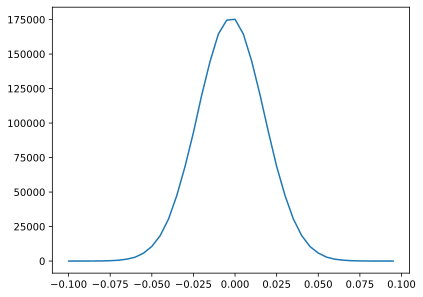

In [15]:
### --- Para el Ejercicio 2: Encontrar la ruta hacia los pesos de atención
yh, xh = np.histogram(
    model.transformerBlocks[1].attn.QKV.weight.detach().cpu(),
    bins=np.linspace(-0.1, 0.1, 41)
)
plt.plot(xh[:-1], yh);

### ¡Ahora a entrenar el modelo!

In [16]:
num_samples = 501

# Inicializar las pérdidas
train_loss = []
test_loss = []
attn_W_dists = np.zeros((num_samples, 100))
attn_W_stds = np.zeros((num_samples, len(model.transformerBlocks)))

for sampli in range(num_samples):

  # Obtener un lote de datos
  X, y = get_data_batch()

  # Mover los datos a la GPU
  X, y = X.to(device), y.to(device)

  # Limpiar los gradientes previos
  model.zero_grad(set_to_none=True)

  # Paso hacia adelante (forward pass)
  log_probs = model(X)

  # Calcular las pérdidas sobre la palabra objetivo final (redimensionada)
  loss = loss_function(log_probs.view(-1, log_probs.shape[-1]), y.view(-1))

  # Retropropagación (backpropagation)
  loss.backward()
  optimizer.step()

  # Almacenar la pérdida por muestra
  train_loss.append(loss.item())

  ### --- Para el Ejercicio 2
  # Obtener las distribuciones de los pesos de atención
  hidx = 4  # Solo de un bloque de transformer
  qkvWeights = (
      model.transformerBlocks[hidx].attn.QKV.weight.detach().cpu().flatten()
  )
  yh, xh = np.histogram(qkvWeights, bins=np.linspace(-0.1, 0.1, 101))
  attn_W_dists[sampli, :] = yh

  for hidx in range(len(model.transformerBlocks)):
    qkvWeights = (
        model.transformerBlocks[hidx].attn.QKV.weight.detach().cpu().flatten()
    )
    attn_W_stds[sampli, hidx] = torch.std(qkvWeights)
  ### --------------------------

  # Evaluar el modelo con el conjunto de prueba
  if sampli % 50 == 0:
    with torch.no_grad():
      eval_batch_losses = []
      # Promediar sobre múltiples lotes para suavizar la varianza estocástica
      for _ in range(15):
        X_test, y_test = get_data_batch(False)  # False -> datos de prueba
        X_test, y_test = X_test.to(device), y_test.to(device)
        out = model(X_test)
        thisloss = loss_function(out.view(-1, out.shape[-1]), y_test.view(-1))
        eval_batch_losses.append(thisloss.item())

      # Guardar el promedio de pérdida de prueba
      test_loss.append(np.mean(eval_batch_losses))

      # Actualizar nuestro progreso :)
      print(
          f'Muestra {sampli:4}, pérdida entrenamiento: {train_loss[-1]:5.2f},'
          f' pérdida prueba: {test_loss[-1]:5.2f}'
      )

Muestra    0, pérdida entrenamiento: 10.83, pérdida prueba: 10.78
Muestra   50, pérdida entrenamiento:  8.79, pérdida prueba:  8.90
Muestra  100, pérdida entrenamiento:  7.09, pérdida prueba:  7.56
Muestra  150, pérdida entrenamiento:  6.42, pérdida prueba:  6.93
Muestra  200, pérdida entrenamiento:  6.11, pérdida prueba:  6.73
Muestra  250, pérdida entrenamiento:  5.96, pérdida prueba:  6.51
Muestra  300, pérdida entrenamiento:  5.85, pérdida prueba:  6.44
Muestra  350, pérdida entrenamiento:  5.49, pérdida prueba:  6.33
Muestra  400, pérdida entrenamiento:  5.40, pérdida prueba:  6.21
Muestra  450, pérdida entrenamiento:  5.29, pérdida prueba:  6.25
Muestra  500, pérdida entrenamiento:  5.23, pérdida prueba:  6.02


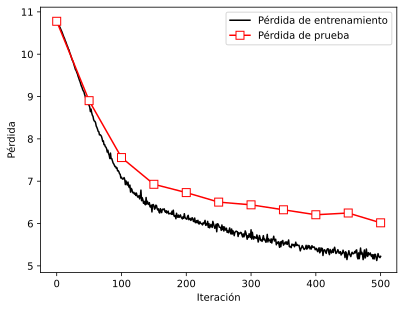

In [17]:
# Graficar las pérdidas
plt.plot(train_loss, 'k', label='Pérdida de entrenamiento')
plt.plot(range(0, num_samples, 50), test_loss, 'rs-', markerfacecolor='w', markersize=8, label='Pérdida de prueba')

plt.legend()
plt.gca().set(xlabel='Iteración', ylabel='Pérdida')
plt.show()

### Ejercicio 2: Distribución de los pesos de atención durante el entrenamiento

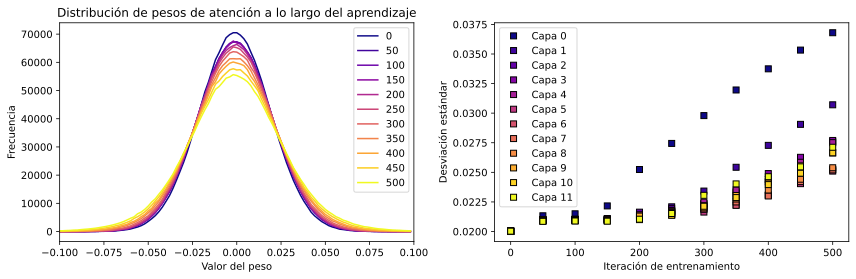

In [18]:
# Colores para cada línea
linecolors = plt.cm.plasma(np.linspace(0, 1, num_samples))

_, axs = plt.subplots(1, 2, figsize=(12, 4))

for i in range(0, num_samples, 50):
  axs[0].plot(
      xh[:-1], attn_W_dists[i, :], color=linecolors[i], label=f'{i}'
  )

axs[0].legend()
axs[0].set(
    xlim=xh[[0, -1]],
    xlabel='Valor del peso',
    ylabel='Frecuencia',
    title='Distribución de pesos de atención a lo largo del aprendizaje',
)

# Graficar las desviaciones estándar
linecolors = plt.cm.plasma(np.linspace(0, 1, attn_W_stds.shape[1]))
for i in range(attn_W_stds.shape[1]):
  axs[1].plot(
      range(0, num_samples, 50),
      attn_W_stds[::50, i],
      'ks',
      markerfacecolor=linecolors[i],
      label=f'Capa {i}',
  )

axs[1].set(
    xlabel='Iteración de entrenamiento', ylabel='Desviación estándar'
)
axs[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# Podemos observar como se van volviendo mas amplias capturando el contexto esto indica que el modelo puede tomar mayor variabilidad (vemos que no todas se ensanchan al mismo tiempo )

Analisis de la **dinámica de aprendizaje interna y la evolución de los parámetros de autoatención ($W_{QKV}$)** a lo largo de 500 iteraciones de optimización.

---

### 1. Panel Izquierdo: Distribución de pesos a lo largo del aprendizaje

* **Ensanchamiento de la campana (Aumento de varianza):** Al inicio (iteración 0, curva azul oscuro), los pesos parten de una distribución normal estrecha con media $\mu = 0$ y desviación estándar $\sigma = 0.02$ (definida en `weightInits`). A medida que el entrenamiento avanza (curvas cálidas/amarillas hacia la iteración 500), el pico central en $0$ desciende de ~70,000 a ~50,000 y las colas se expanden hacia $[-0.075, 0.075]$.
* **Conservación de la simetría ($\mu \approx 0$):** La distribución permanece centrada en cero. Esto confirma que el optimizador (AdamW) no genera un sesgo direccional no deseado en las proyecciones lineales, y que el *weight decay* ($\lambda = 0.01$) actúa correctamente como regularizador $L_2$, evitando que los pesos exploten hacia magnitudes descontroladas.
* **Especialización funcional:** El ensanchamiento de las colas es la firma empírica del aprendizaje: para que los cabezales calculen similitudes selectivas mediante producto punto ($Q K^T$), ciertos pesos deben adquirir magnitudes mayores para amplificar patrones sintácticos o semánticos relevantes en el texto.

---

### 2. Panel Derecho: Desviación estándar por capa

* **Punto de partida idéntico ($\sigma = 0.02$):** En la iteración 0, todas las capas (Capa 0 a Capa 11) arrancan exactamente en $0.02$, validando que el método recursivo `self.apply(self.weightInits)` inicializó cada bloque de forma consistente.
* **Comportamiento atípico de la Capa 0 (cuadrado azul superior):**
* La **Capa 0** muestra un crecimiento drástico de su desviación estándar, alcanzando $\sigma \approx 0.035$ en la iteración 500, despegándose por completo del resto.
* *Razón arquitectónica:* Es la primera capa que recibe directamente la suma de los embeddings de tokens y posiciones (`wte + wpe`). Al estar en contacto inmediato con el espacio discreto de entrada, debe absorber y transformar representaciones brutas de palabras y posiciones en espacios contextuales útiles, experimentando gradientes más directos y de mayor magnitud durante las primeras etapas.


* **Estratificación jerárquica (Capas intermedias y profundas):**
* Las capas intermedias (Capas 1 a 6, tonos púrpuras y rosas) crecen a un ritmo moderado ($\sigma \in [0.027, 0.030]$).
* Las capas más profundas (Capas 7 a 11, tonos anaranjados y amarillos) se mantienen más comprimidas ($\sigma \in [0.024, 0.026]$).
* *Dinámica de flujo de gradiente (Pre-LN):* En arquitecturas Pre-LayerNorm, el gradiente a través de las conexiones residuales fluye sin atenuación directa hacia las capas inferiores, lo que permite que las capas tempranas aprendan patrones estructurales rápidos mientras las capas superiores realizan ajustes finos sobre representaciones ya abstraídas.



---

### Diagnóstico técnico del entrenamiento

1. **Estabilidad numérica:** El incremento monótono y gradual de las desviaciones estándar descarta tanto la **desaparición del gradiente** (*vanishing gradients*, donde los puntos habrían quedado estancados en 0.02) como la **explosión del gradiente** (*exploding gradients*, donde las desviaciones habrían crecido de forma abrupta o discontinua).
2. **Capacidad de generalización:** Las capas no se saturan prematuramente tras 500 iteraciones; el modelo aún se encuentra en una fase saludable de adaptación a la sintaxis del texto de Gutenberg.